<a href="https://colab.research.google.com/github/experienciarg200-alt/Python-con-Pandas/blob/main/Actividad8RLineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC4029 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 8**
Regresión Lineal

---

*   NOMBRES:Equipo No. 15 ____
            María Del Carmen Guerrero Germám, MAT. A01796959___
            Anthony Geraldo Gutarra Sánchez, MAT. A01840622___
            Rafael Augusto Guerrero Guerrero, MAT. A01796515___
            Luis Pablo Guerrero, MAT. A01840428


In [182]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [183]:
#import os
#DIR = "/content/drive/MyDrive/Colab Notebooks/MNA/TC4029 - Ciencia y analítica de datos/Semana 8/Actividad8_RLineal"
#os.chdir(DIR)

In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [185]:
insurance_df = pd.read_csv('insurance.csv')
insurance_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# **Parte 1**. EDA

Efectúa una exploración inicial de los datos a través de:

1a) Estadísticas descriptivas para todas las variables del dataframe.

In [186]:
insurance_df.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


1b) Búsqueda de valores faltantes.

In [187]:
insurance_df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


1c) Histrogramas y boxplots para las variables cuantitativas y diagramas de barras con la frecuencia para las variables categóricas.

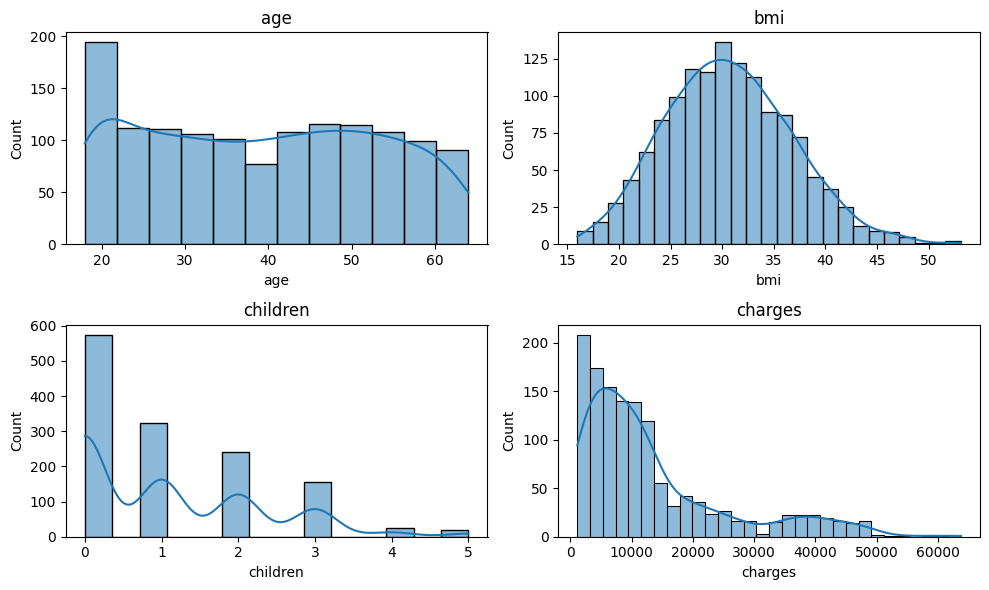

In [188]:
#Identificando variables cuantitativas
num_vars = ['age', 'bmi', 'children', 'charges']

#Crear el histograma para cada variable
plt.figure(figsize=(10,6))

for i, var in enumerate(num_vars, 1):
    plt.subplot(2, 2, i)
    sns.histplot(insurance_df[var], kde=True)
    plt.title(var)

plt.tight_layout()
plt.show()

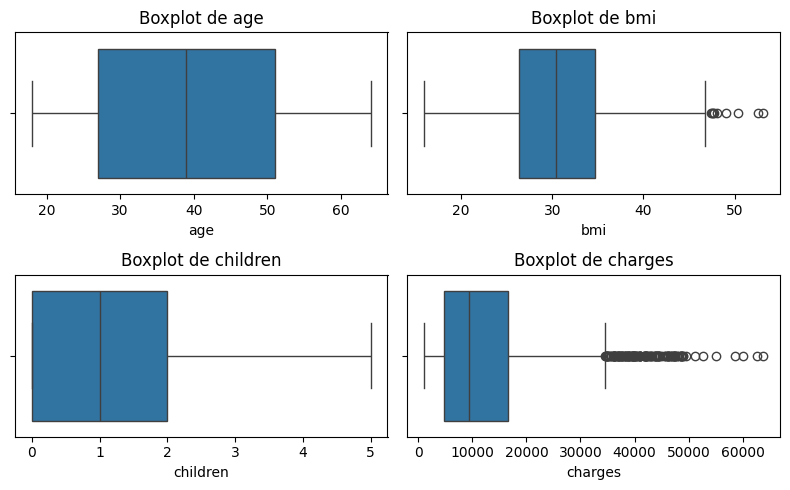

In [189]:
#Identificando las variiables
num_vars = ['age', 'bmi', 'children', 'charges']

#Crear los boxplot
plt.figure(figsize=(8,5))

for i, var in enumerate(num_vars, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=insurance_df[var])
    plt.title(f'Boxplot de {var}')

plt.tight_layout()
plt.show()

Para responder los siguientes cuestionamientos, genera los gráficos indicados:

2a) ¿Hay diferencias significativas de las primas según el sexo? Compara la distribución de la variable `charges` por medio de un boxplot.

R/ Las medianas de charges son un tanto similares en ambos sexos. La dispersión tambien es parecida, existen outliers en ambos grupos. No existen diferencias significativas en las primas por razón de sexo.

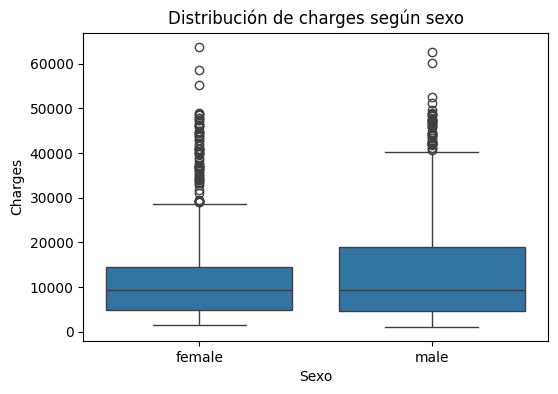

In [190]:
plt.figure(figsize=(6,4))

sns.boxplot(x='sex', y='charges', data=insurance_df)

plt.title('Distribución de charges según sexo')
plt.xlabel('Sexo')
plt.ylabel('Charges')

plt.show()

2b) Crea un diagrama de dispersión de `charges` versus el `bmi` que incorpore la distinción por las categorías `smoker` y `children` (tip: utiliza el parámetro `size`) ¿Hay alguna conclusión importante que se derive del gráfico?

R/ El gráfico muestra que el factor que más influye en el costo del seguro es si la persona fuma. Los fumadores presentan primas significativamente más altas que los no fumadores. También se observa una ligera tendencia de mayores costos a medida que aumenta el BMI, especialmente entre los fumadores. El número de hijos no parece mostrar una relación clara con los cargos.

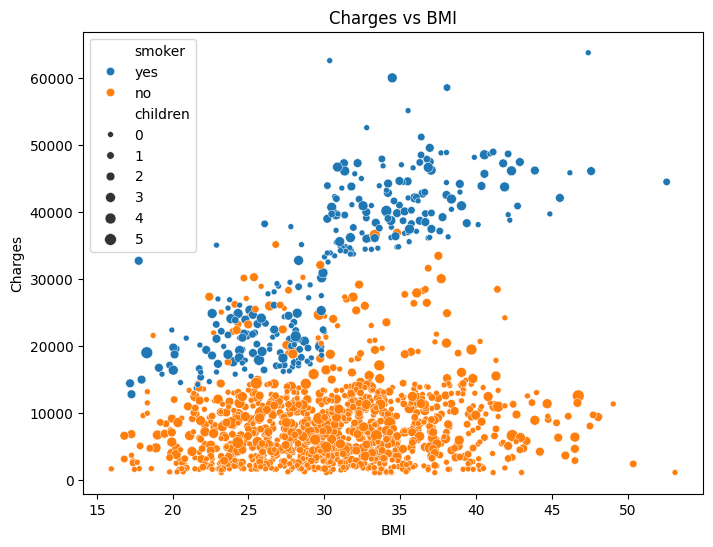

In [191]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='bmi',
    y='charges',
    hue='smoker',
    size='children',
    data=insurance_df )

plt.title('Charges vs BMI')
plt.xlabel('BMI')
plt.ylabel('Charges')

plt.show()

2c) Elabora un mapa de calor que muestre la correlación de las variables numéricas.

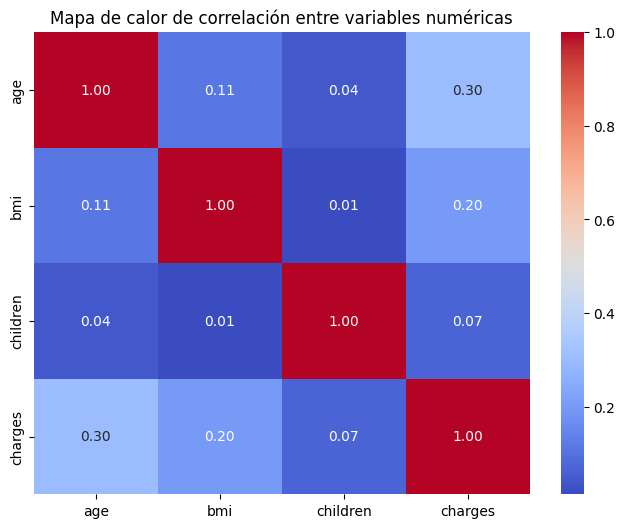

In [192]:
plt.figure(figsize=(8,6))

corr = insurance_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Mapa de calor de correlación entre variables numéricas")
plt.show()

Obtén un dataframe con las observaciones que tengan valores atípicos en `charges`.

3a) ¿Cuál es el promedio de `age` y de `bmi` en el dataframe de valores atípicos obtenido?

In [193]:
#Calcualar límites para detectar oultliers
Q1 = insurance_df['charges'].quantile(0.25)
Q3 = insurance_df['charges'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

#Crear dataframe con los valores atipicos
outliers_charges = insurance_df[
    (insurance_df['charges'] < limite_inferior) |
    (insurance_df['charges'] > limite_superior)
]

outliers_charges


,age,sex,bmi,children,smoker,region,charges
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
29,31,male,36.300,2,yes,southwest,38711.00000
30,22,male,35.600,0,yes,southwest,35585.57600
...,...,...,...,...,...,...,...
1300,45,male,30.360,0,yes,southeast,62592.87309
1301,62,male,30.875,3,yes,northwest,46718.16325
1303,43,male,27.800,0,yes,southwest,37829.72420
1313,19,female,34.700,2,yes,southwest,36397.57600


In [194]:
outliers_charges[['age', 'bmi']].mean()

,0
age,41.079137
bmi,35.564604


3b) ¿Qué porcentaje de estas observaciones (en el dataframe de valores atípicos obtenidos) se corresponden a mujeres y a hombres? ¿A fumadores y no fumadores?

In [195]:
#Porcentaje  de fumadores por sexo
(outliers_charges['sex'].value_counts(normalize=True) * 100)

,proportion
sex,
male,64.028777
female,35.971223


In [196]:
(outliers_charges['smoker'].value_counts(normalize=True) * 100)

,proportion
smoker,
yes,97.841727
no,2.158273


# **Parte 2**. Preprocesamiento

4. Separa las variables del dataframe: en `X` coloca los predictores y en `y` la variable de respuesta o salida (`charges`).

In [197]:
#Separación de la variable predictora de la variable objeto
X = insurance_df.drop('charges', axis=1)
y = insurance_df['charges']

5. Divide el conjunto en entrenamiento y prueba (80:20) considerando:


*   El parámetro `random_state` con el valor de 1 para garantizar reproducibilidad.
*   Analiza los diagramas de barras obtenidos en el ejercicio 1c. Con los resultados observados, es conveniente usar la variable `smoker` en la estrategia de estratificación.
*   Como ya tienes separadas en `X` e `y` los predictores y salida, consulta cómo ejecutar la función `train_test_split()` para obtener `Xtrain, Xtest, ytrain, ytest` en una única instrucción.

In [198]:
#Importar la función y división de los datos
from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    stratify=X['smoker']
)

print(Xtrain.shape)
print(Xtest.shape)
print(ytrain.shape)
print(ytest.shape)

#Los resultados indican> El conjunto de entrenamiento tieme: 1070 filas; 6 columnas.
#El conjunto de prueba tiene: 268 observaciones, 6 predictores. Esto corresponde al 20% del dataset

(1070, 6)
(268, 6)
(1070,)
(268,)


6. Prepara un transformador, denominado `preprocessing`, para aplicar escalamiento *MinMax* a los predictores numéricos y codificación *one-hot* a los categóricas.

In [199]:
#Se identifican las columnas
num_cols = ['age', 'bmi', 'children']
cat_cols = ['sex', 'smoker', 'region']

#Se importan los transformadores
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

#Se crea el nuevo transformador
preprocessing = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), num_cols),
        ('cat', OneHotEncoder(), cat_cols)
    ]
)


# **Parte 3**. Entrenando y evaluando el modelo de RL

7. Ejecuta un pipeline con el transformador creado y el algoritmo de regresión lineal para entrenar un modelo denominado `lr_model`.

Evalúa el modelo en el conjunto de prueba y obtén la raíz del error cuadrático medio (`RMSE`) y la métrica `R` cuadrado ($R^2$). Aunque ésta última la estudiarás a detalle la próxima semana, ahora sólo debes saber que toma valores entre 0 y 1, donde 1 indica un ajuste perfecto y, por tanto, un modelo muy fiable para las previsiones futuras. La función de scikit-learn que determina esta métrica es: [`r2_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html)

In [200]:
#Se importaron librerias por si habían faltantes
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

#Se crea el pipeline
lr_model = Pipeline([
    ('preprocessing', preprocessing),
    ('regression', LinearRegression())
])

lr_model.fit(Xtrain, ytrain)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat', OneHotEncoder(),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('regression', LinearRegression())])

In [201]:
#RMSE mide el error promedio de las predicciones
y_pred = lr_model.predict(Xtest)
rmse = np.sqrt(mean_squared_error(ytest, y_pred))
print("RMSE:", rmse)

# r2 indica qué porcentaje de la variabilidad chrges explica el modelo
r2 = r2_score(ytest, y_pred)
print("R2:", r2)

RMSE: 5698.759784532354
R2: 0.7538547215244327


**Valora el rendimiento del modelo con los siguientes cambios:**


8. Reemplaza los outliers de `charges` con el límite superior (`Q3 + 1.5 * IQR`). Haz el cambio en ambos conjuntos: `ytrain` y `ytest`, previo a la aplicación del mismo pipeline. Guarda el modelo como `lr_model2`.


In [202]:
#Datos de entrenamiento para evitar sesgos
Q1 = ytrain.quantile(0.25)
Q3 = ytrain.quantile(0.75)

IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

#Se sustituye valores del límite por el propio límite

ytrain_capped = ytrain.clip(upper=limite_superior)
ytest_capped = ytest.clip(upper=limite_superior)

#Creando el nuevo pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

lr_model2 = Pipeline([
    ('preprocessing', preprocessing),
    ('regression', LinearRegression())
])


In [203]:
lr_model2.fit(Xtrain, ytrain_capped)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat', OneHotEncoder(),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('regression', LinearRegression())])

In [204]:
#Entrenando nuevamente el modelo
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr_model2.fit(Xtrain, ytrain_capped)

#Hacer predicciones
y_pred2 = lr_model2.predict(Xtest)

#Calcular métricas
rmse2 = np.sqrt(mean_squared_error(ytest_capped, y_pred2))
r2_2 = r2_score(ytest_capped, y_pred2)

print("RMSE:", rmse2)
print("R2:", r2_2)


RMSE: 4995.027100717609
R2: 0.760567540460912


9. Prepara otro transformador, denominado `preprocessing2`, para aplicar escalamiento estándar a los predictores numéricos y codificación ordinal a los categóricas. Aplícalo en un nuevo pipeline utilizando nuevamente regresión lineal. Guarda el modelo como `lr_model3`.

**Nota.** Los cambios se ejecutan de manera consecutiva, por ejemplo: el reemplazo de los outliers también se ejecuta previo al transformador `preprocessing2` y así sucesivamente.

In [205]:
#Importar los nuevos transformadores
num_cols = ['age', 'bmi', 'children']
cat_cols = ['sex', 'smoker', 'region']

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer

#Creación del transformador
preprocessing2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OrdinalEncoder(), cat_cols)
    ]
)

#Creación del pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

lr_model3 = Pipeline([
    ('preprocessing', preprocessing2),
    ('regression', LinearRegression())
])

lr_model3.fit(Xtrain, ytrain_capped)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat', OrdinalEncoder(),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('regression', LinearRegression())])

In [206]:
#Evaluación del modelo
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred3 = lr_model3.predict(Xtest)

rmse3 = np.sqrt(mean_squared_error(ytest_capped, y_pred3))
r2_3 = r2_score(ytest_capped, y_pred3)

print("RMSE:", rmse3)
print("R2:", r2_3)

RMSE: 4994.25886338128
R2: 0.760641184429659


10. Utiliza regresión polinomial para verificar si se produce un mejor ajuste. Intenta con varios grados, aunque debes dejar en el código sólo el de mejor rendimiento. Guarda el modelo como `lr_model4`.

In [207]:
#Probando regrasión para el mejor ajeste
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

grados = [1, 2, 3, 4]

for g in grados:
    model = Pipeline([
        ('preprocessing', preprocessing2),
        ('poly', PolynomialFeatures(degree=g, include_bias=False)),
        ('regression', LinearRegression())
    ])

    model.fit(Xtrain, ytrain_capped)
    y_pred = model.predict(Xtest)

    rmse = np.sqrt(mean_squared_error(ytest_capped, y_pred))
    r2 = r2_score(ytest_capped, y_pred)

    print(f"Grado {g} → RMSE: {rmse:.2f} | R2: {r2:.4f}")

Grado 1 → RMSE: 4994.26 | R2: 0.7606
Grado 2 → RMSE: 4384.47 | R2: 0.8155
Grado 3 → RMSE: 4467.68 | R2: 0.8085
Grado 4 → RMSE: 4907.38 | R2: 0.7689


In [208]:
#Grado 2 resultó ser el mejor resultado. Se carga solo este, guardando el pipeline
lr_model4 = Pipeline([
    ('preprocessing', preprocessing2),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('regression', LinearRegression())
])

lr_model4.fit(Xtrain, ytrain_capped)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat', OrdinalEncoder(),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('poly', PolynomialFeatures(include_bias=False)),
                ('regression', LinearRegression())])